In [2]:
import os
import numpy as np
import subprocess
import cantera as ct
import matplotlib.pyplot as plt
%matplotlib inline


# Run baseline and coverage-dependent RMG jobs

This should take less than 5 minutes

In [8]:
base_rmg_run_dir = os.path.join('temp', 'base_rmg_run')
cov_dep_rmg_run_dir = os.path.join('temp', 'cov_dep_rmg_run')
os.makedirs(base_rmg_run_dir, exist_ok=True)
os.makedirs(cov_dep_rmg_run_dir, exist_ok=True)

input_file = """
# Data sources
database(
    thermoLibraries=['covDepSurfaceThermoPt111', 'surfaceThermoPt111', 'primaryThermoLibrary', 'thermo_DFT_CCSDTF12_BAC','DFT_QCI_thermo'],
    reactionLibraries = [
    ('Surface/Methane/Deutschmann_Pt', False),
    ('Surface/Methane/Vlachos_Pt111', False),
    'BurkeH2O2inArHe'],
    seedMechanisms = [],
    kineticsDepositories = ['training'],
    kineticsFamilies =['surface','default'],
    kineticsEstimator = 'rate rules',
)

catalystProperties( # default values for Pt(111)
    metal = 'Pt111',
    thermoCoverageDependence = False,
)

# List of species
species(
    label='X',
    reactive=True,
    structure=adjacencyList("1 X u0"),
)

species(
    label='CH4',
    reactive=True,
    structure=SMILES("[CH4]"),
)
species(
    label='O2',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u1 p2 c0 {2,S}
    2 O u1 p2 c0 {1,S}
    '''),
)

species(
    label='Ar',
    reactive=False,
    structure=SMILES("[Ar]"),
)

species(
    label='CO2',
    reactive=True,
    structure=SMILES("O=C=O"),
)

species(
    label='H2O',
    reactive=True,
    structure=SMILES("O"),
)

species(
    label='H2',
    reactive=True,
    structure=SMILES("[H][H]"),
)

species(
    label='CO',
    reactive=True,
    structure=SMILES("[C-]#[O+]"),
)

species(
    label='C2H6',
    reactive=True,
    structure=SMILES("CC"),
)

species(
    label='CH2O',
    reactive=True,
    structure=SMILES("C=O"),
)

species(
    label='CH3',
    reactive=True,
    structure=SMILES("[CH3]"),
)

species(
    label='C3H8',
    reactive=True,
    structure=SMILES("CCC"),
)

species(
    label='H',
    reactive=True,
    structure=SMILES("[H]"),
)

species(
    label='C2H5',
    reactive=True,
    structure=SMILES("C[CH2]"),
)

species(
    label='CH3OH',
    reactive=True,
    structure=SMILES("CO"),
)

species(
    label='HCO',
    reactive=True,
    structure=SMILES("[CH]=O"),
)

species(
    label='CH3CHO',
    reactive=True,
    structure=SMILES("CC=O"),
)

species(
    label='OH',
    reactive=True,
    structure=SMILES("[OH]"),
)

species(
    label='C2H4',
    reactive=True,
    structure=SMILES("C=C"),
)

species(
    label='CH3CH',
    reactive=True,
    structure=SMILES("[CH]C"),
)

species(
    label='CH3OO',
    reactive=True,
    structure=SMILES("CO[O]"),
)

species(
    label='HX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 H u0 p0 c0 {2,S}
    2 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='CO2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {3,D}
    2 O u0 p2 c0 {3,D}
    3 C u0 p0 c0 {1,D} {2,D}
    4 X u0 p0 c0
    '''),
)

species(
    label='COX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 C u0 p0 c0 {1,D} {3,D}
    3 X u0 p0 c0 {2,D}
    '''),
)

species(
    label='CH4X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 H u0 p0 c0 {1,S}
    5 H u0 p0 c0 {1,S}
    6 X u0 p0 c0
    '''),
)

species(
    label='OX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 X u0 p0 c0 {1,D}
    '''),
)

species(
    label='CH2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,D}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 X u0 p0 c0 {1,D}
    '''),
)

species(
    label='CH3X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 H u0 p0 c0 {1,S}
    5 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='CHX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,T}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0 {1,T}
    '''),
)

species(
    label='CX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,Q}
    2 X u0 p0 c0 {1,Q}
    '''),
)

species(
    label='H2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 H u0 p0 c0 {2,S}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0
    '''),
)

species(
    label='OHX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,S} {3,S}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='H2OX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,S} {3,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 X u0 p0 c0
    '''),
)

species(
    label='CHOX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 C u0 p0 c0 {1,D} {3,S} {4,S}
    3 H u0 p0 c0 {2,S}
    4 X u0 p0 c0 {2,S}
    '''),
)

surfaceReactor(
    temperature=(600,'K'),
    initialPressure=(1.0, 'bar'),
    initialGasMoleFractions={
        "CH4": 0.108574,
        "O2": 0.02088,
        "Ar": 0.78547,
    },
    initialSurfaceCoverages={
        "X": 1.0,
    },
    surfaceVolumeRatio=(1.e5, 'm^-1'),
    terminationConversion = { "CH4":0.95,},
    terminationTime=(10., 's'),
    # terminationConversion={'O2': 0.99,},
    terminationRateRatio=0.05
)

surfaceReactor(
    temperature=(2000,'K'),
    initialPressure=(1.0, 'bar'),
    initialGasMoleFractions={
        "CH4": 0.041866,
        "O2": 0.03488,
        "Ar": 0.131246,
    },
    initialSurfaceCoverages={
        "X": 1.0,
    },
    surfaceVolumeRatio=(1.e5, 'm^-1'),
    terminationConversion = { "CH4":0.95,},
    terminationTime=(10., 's'),
    # terminationConversion={'O2': 0.99,},
    terminationRateRatio=0.05
)


simulator(
    atol=1e-18,
    rtol=1e-12,
)

model(
    toleranceKeepInEdge=0.0,
    toleranceMoveToCore=1e-1,
# inturrupt tolerance was 0.1 wout pruning, 1e8 w pruning on
    toleranceInterruptSimulation=1e8,
    maximumEdgeSpecies=500000,
    maxNumSpecies=44,
# PRUNING: uncomment to prune
#    minCoreSizeForPrune=50,
# prune before simulation based on thermo
#    toleranceThermoKeepSpeciesInEdge=0.5,
# prune rxns from edge that dont move into core
#    minSpeciesExistIterationsForPrune=2,
# FILTERING: set so threshold is slightly larger than max rate constants
#    filterReactions=True,
#    filterThreshold=5e8, # default value
)

options(
    units='si',
    saveRestartPeriod=None,
    generateOutputHTML=True,
    generatePlots=False,
    saveEdgeSpecies=True,
    saveSimulationProfiles=True,
)

generatedSpeciesConstraints(
    allowed=['input species','reaction libraries'],
    maximumSurfaceSites=1,
)
"""

rmgpy_path = '../rmg.py' # Change to your rmg.py path


input_path = os.path.join(base_rmg_run_dir, 'input.py')
with open(input_path,'w') as f:
    f.write(input_file)
print(f"Running RMG with input file at {input_path}...")
subprocess.check_call(['python', rmgpy_path, input_path])


# repeat for coverage dependent run
input_path = os.path.join(cov_dep_rmg_run_dir, 'input.py')
input_file = input_file.replace('thermoCoverageDependence = False', 'thermoCoverageDependence = True')
with open(input_path,'w') as f:
    f.write(input_file)
print(f"Running RMG with input file at {input_path}...")
subprocess.check_call(['python', rmgpy_path, input_path])

Running RMG with input file at temp/cov_dep_rmg_run/input.py...
Global RMG Settings:
   database.directory   = /home/moon/rmg/RMG-database/input (Default, relative to RMG-Py source code)
   test_data.directory  = /home/moon/rmg/RMG-Py/test/rmgpy/test_data (Default, relative to RMG-Py source code)
RMG execution initiated at Tue Apr  7 16:44:57 2026

#########################################################
# RMG-Py - Reaction Mechanism Generator in Python       #
# Version: 3.3.0                                        #
# Authors: RMG Developers (rmg_dev@mit.edu)             #
# P.I.s:   William H. Green (whgreen@mit.edu)           #
#          Richard H. West (r.west@neu.edu)             #
# Website: http://reactionmechanismgenerator.github.io/ #
#########################################################

The current git HEAD for RMG-Py is:
	b'5bbd2707ea570c5a4fb681f0baa071fb1058ad24'
	b'Mon Apr 6 15:20:46 2026 -0400'

The current git HEAD for RMG-database is:
	b'edfb0e5d715146fd0edd220

/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2322: LinAlgWarning: Ill-conditioned matrix (rcond=9.78829e-18): result may not be accurate.
  fu = func(x, *args)
/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2322: LinAlgWarning: Ill-conditioned matrix (rcond=8.30526e-20): result may not be accurate.
  fu = func(x, *args)
/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2322: LinAlgWarning: Ill-conditioned matrix (rcond=1.38146e-20): result may not be accurate.
  fu = func(x, *args)
/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2322: LinAlgWarning: Ill-conditioned matrix (rcond=8.43874e-21): result may not be accurate.
  fu = func(x, *args)
/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2322: LinAlgWarning: Ill-conditioned matrix (rcond=2.11249e-21): result may not be ac

Adding reaction library Surface/Methane/Deutschmann_Pt to model edge...

Summary of Model Enlargement
---------------------------------
Added 0 new core species
Created 0 new edge species
Added 0 new core reactions
Created 18 new edge reactions
    X(1) + X(1) + H2(6) <=> HX(21) + HX(21)
    X(1) + X(1) + O2(3) <=> OX(25) + OX(25)
    X(1) + X(1) + CH4(2) <=> HX(21) + CH3X(27)
    X(1) + OX(25) + CH4(2) <=> OHX(31) + CH3X(27)
    X(1) + OHX(31) + CH4(2) <=> H2OX(32) + CH3X(27)
    X(1) + H2O(5) <=> H2OX(32)
    X(1) + CO2(4) <=> CO2X(22)
    X(1) + CO(7) <=> COX(23)
    OX(25) + CX(29) <=> X(1) + COX(23)
    OX(25) + COX(23) <=> X(1) + CO2X(22)
    HX(21) + CO2X(22) <=> OHX(31) + COX(23)
    HX(21) + CH2X(26) <=> X(1) + CH3X(27)
    HX(21) + CHX(28) <=> X(1) + CH2X(26)
    X(1) + CHX(28) <=> HX(21) + CX(29)
    OX(25) + HX(21) <=> X(1) + OHX(31)
    OX(25) + H2OX(32) <=> OHX(31) + OHX(31)
    H2(6) + CX(29) <=> CH2X(26)
    HX(21) + OHX(31) <=> X(1) + H2OX(32)

After model enlargement:

0

# Simulate the RMG mechanisms

In [19]:
# Load mechanism
base_mech_yaml = os.path.join(base_rmg_run_dir, 'cantera', 'chem_annotated.yaml')
gas_base = ct.Solution(base_mech_yaml)
surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
print(f'Base mechanism contains {gas_base.n_species} gas species and {surf_base.n_species} surface species')


cov_dep_mech_yaml = os.path.join(cov_dep_rmg_run_dir, 'cantera', 'chem_annotated.yaml')
gas_cov_dep = ct.Solution(cov_dep_mech_yaml)
surf_cov_dep = ct.Interface(cov_dep_mech_yaml, 'SURF0', [gas_cov_dep])
print(f'Coverage-dependent mechanism contains {gas_cov_dep.n_species} gas species and {surf_cov_dep.n_species} surface species')

def get_i_thing(ref_composition, phase):
	for i in range(phase.n_species):
		if phase.species()[i].composition == ref_composition:
			return i
	return -1


# simulate
# Set initial conditions
T = 1000.0  # K
P = 100000.0  # Pa
i_CO_base = get_i_thing({'C': 1, 'O': 1}, gas_base)
i_H2_base = get_i_thing({'H': 2}, gas_base)

initial_mole_fractions = f'{gas_base.species_names[i_CO_base]}: 0.5, {gas_base.species_names[i_H2_base]}: 0.5'
initial_surface_coverages = 'X(1): 1.0'


gas_base.TPX = T, P, initial_mole_fractions
gas_reactor = ct.IdealGasReactor(gas_base, energy='off')  # energy off makes it isothermal

surf_base.TP = T, P                
surf_base.coverages = initial_surface_coverages
surf_reactor = ct.ReactorSurface(surf_base, gas_reactor)

net = ct.ReactorNet([gas_reactor])

times_base = [net.time]
gas_concentrations_base = [gas_base.X]
surf_concentrations_base = [surf_base.coverages]

termination_time = 1.0  # s
while net.time < termination_time:
    net.step()
    times_base.append(net.time)
    gas_concentrations_base.append(gas_base.X)
    surf_concentrations_base.append(surf_base.coverages)

times_base = np.array(times_base)
gas_concentrations_base = np.array(gas_concentrations_base)
surf_concentrations_base = np.array(surf_concentrations_base)


# --------------------- Run coverage-dependent simulation ---------------------
i_CO_cov_dep = get_i_thing({'C': 1, 'O': 1}, gas_cov_dep)
i_H2_cov_dep = get_i_thing({'H': 2}, gas_cov_dep)

initial_mole_fractions = f'{gas_cov_dep.species_names[i_CO_cov_dep]}: 0.5, {gas_cov_dep.species_names[i_H2_cov_dep]}: 0.5'
initial_surface_coverages = 'X(1): 1.0'


gas_cov_dep.TPX = T, P, initial_mole_fractions
gas_reactor = ct.IdealGasReactor(gas_cov_dep, energy='off')  # energy off makes it isothermal

surf_cov_dep.TP = T, P                
surf_cov_dep.coverages = initial_surface_coverages
surf_reactor = ct.ReactorSurface(surf_cov_dep, gas_reactor)

net = ct.ReactorNet([gas_reactor])

times_cov_dep = [net.time]
gas_concentrations_cov_dep = [gas_cov_dep.X]
surf_concentrations_cov_dep = [surf_cov_dep.coverages]

termination_time = 1.0  # s
while net.time < termination_time:
    net.step()
    times_cov_dep.append(net.time)
    gas_concentrations_cov_dep.append(gas_cov_dep.X)
    surf_concentrations_cov_dep.append(surf_cov_dep.coverages)

times_cov_dep = np.array(times_cov_dep)
gas_concentrations_cov_dep = np.array(gas_concentrations_cov_dep)
surf_concentrations_cov_dep = np.array(surf_concentrations_cov_dep)


Base mechanism contains 23 gas species and 17 surface species
Coverage-dependent mechanism contains 23 gas species and 17 surface species


/tmp/ipykernel_180850/4041569244.py:4: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'H(12) + X(1) <=> HX(21)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
/tmp/ipykernel_180850/4041569244.py:4: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'OH(17) + X(1) <=> OHX(31)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
/tmp/ipykernel_180850/4041569244.py:10: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'H(12) + X(1) <=> HX(21)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_cov_dep = ct.Interface(cov_dep_mech_yaml, 'SURF0', [gas_cov_dep])
/tmp/ipykernel_180850/4041569244.py:10: UserWarning: StickingRate::validate: 
S

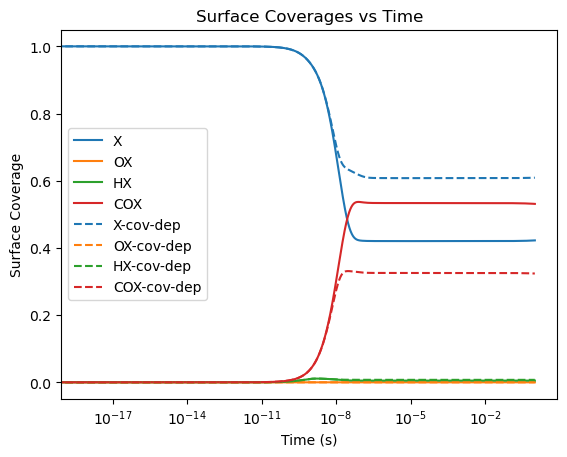

In [20]:
# Plot the results

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot COX, X, OX, HX
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'X': 1}, surf_base)], label='X', color=colors[0])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'O': 1, 'X': 1}, surf_base)], label='OX', color=colors[1])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'H': 1, 'X': 1}, surf_base)], label='HX', color=colors[2])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_base)], label='COX', color=colors[3])

# plot cov-dep
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'X': 1}, surf_cov_dep)], label='X-cov-dep', color=colors[0], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'O': 1, 'X': 1}, surf_cov_dep)], label='OX-cov-dep', color=colors[1], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'H': 1, 'X': 1}, surf_cov_dep)], label='HX-cov-dep', color=colors[2], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_cov_dep)], label='COX-cov-dep', color=colors[3], linestyle='dashed')


plt.xlabel('Time (s)')
plt.ylabel('Surface Coverage')
plt.title('Surface Coverages vs Time')
plt.legend()
plt.xscale('log')
# plt.yscale('log')
plt.savefig('cross_surface_coverages.png')
plt.show()


In [48]:
# Plot the enthalpy of XCO versus coverage

i_XCO_base = get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_base)
i_XCO_cov_dep = get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_cov_dep)


coverages = np.linspace(0, 1, 10)
enthalpies_base = []
enthalpies_cov_dep = []

entropies_base = []
entropies_cov_dep = []

T = 300.0  # K
P = ct.one_atm  # Pa
for coverage in coverages:

    surf_base.TPX = T, P, f'X(1): {1.0 - coverage}, {surf_base.species_names[i_XCO_base]}: {coverage}'
    surf_cov_dep.TPX = T, P, f'X(1): {1.0 - coverage}, {surf_cov_dep.species_names[i_XCO_cov_dep]}: {coverage}'

    enthalpies_base.append(surf_base.standard_enthalpies_RT[i_XCO_base])
    enthalpies_cov_dep.append(surf_cov_dep.standard_enthalpies_RT[i_XCO_cov_dep])

    entropies_base.append(surf_base.standard_entropies_R[i_XCO_base])
    entropies_cov_dep.append(surf_cov_dep.standard_entropies_R[i_XCO_cov_dep])



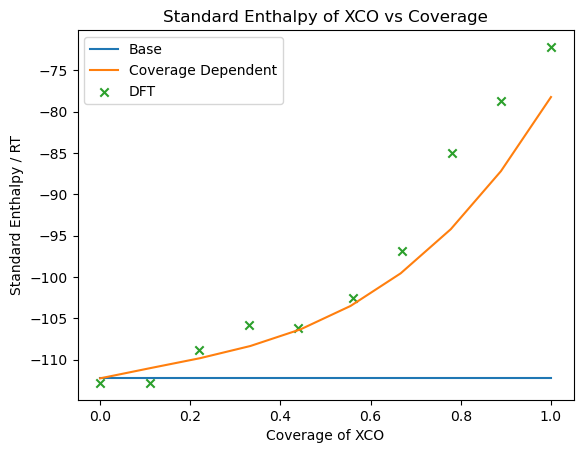

In [ ]:
plt.plot(coverages, enthalpies_base, label='Base', color=colors[0])
plt.plot(coverages, enthalpies_cov_dep, label='Coverage Dependent', color=colors[1])


# these values copied from Cantera example: https://cantera.org/dev/examples/python/thermo/coverage_dependent_surf.html
# provide discrete enthalpy and entropy values calculated with DFT
# array of CO* coverage
dft_covs = [0., 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.0]
# array of nondimensionalized DFT-derived CO* enthalpy values
dft_hrts = [-112.8 , -112.8 , -108.78, -105.76, -106.11, -102.51,  -96.83,
            -85.03,  -78.76,  -72.19]

plt.scatter(dft_covs, dft_hrts, label='DFT', color=colors[2], marker='x')


plt.xlabel('Coverage of XCO')
plt.ylabel('Standard Enthalpy / RT')
plt.title('Standard Enthalpy of XCO vs Coverage')
plt.legend()

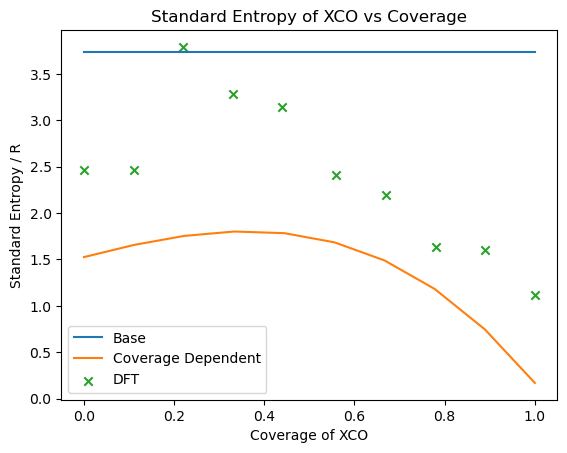

In [54]:
plt.plot(coverages, entropies_base, label='Base', color=colors[0])
plt.plot(coverages, entropies_cov_dep, label='Coverage Dependent', color=colors[1])

# these values copied from Cantera example: https://cantera.org/dev/examples/python/thermo/coverage_dependent_surf.html
# provide discrete enthalpy and entropy values calculated with DFT
# array of CO* coverage
dft_covs = [0., 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.0]

# array of nondimensionalized DFT-derived CO* entropy values
dft_srs = [2.46, 2.46, 3.79, 3.28, 3.14, 2.41, 2.19, 1.63, 1.6 , 1.12]

plt.scatter(dft_covs, dft_srs, label='DFT', color=colors[2], marker='x')


plt.xlabel('Coverage of XCO')
plt.ylabel('Standard Entropy / R')
plt.title('Standard Entropy of XCO vs Coverage')
plt.legend()
